### Zeitreihen - Analyse und Clusteringansätze

Wir betrachten einen öffentlichen Datensatz zur Degradation von Turbofan-Triebwerken (NASA C-MAPSS) und wenden die verschiedenen Methoden Schritt für Schritt an.

**Zum Datensatz:**
- **100 Maschinen** (Triebwerke), jede mit eigener Zeitreihe
- **Zeitachse:** Betriebszyklen (nicht Kalenderzeit) - Zyklus 1, 2, 3, ... bis zum Ausfall
- **21 Sensoren** pro Zyklus (z. B. Temperatur, Druck, Drehzahl)
- Jede Maschine läuft unterschiedlich lange, bis sie ausfällt (letzte Zeile je Maschine = Ausfall)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.signal import correlate
from tslearn.metrics import dtw, cdist_dtw
from tslearn.clustering import TimeSeriesKMeans, KShape
from tslearn.metrics import dtw as dtw_dist_fn
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sklearn.metrics import silhouette_score


plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

url = 'https://raw.githubusercontent.com/hankroark/Turbofan-Engine-Degradation/master/CMAPSSData/train_FD001.txt'
cols = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f'sensor{i}' for i in range(1, 22)]
machines = pd.read_csv(url, sep=r'\s+', header=None, names=cols)

machines.head()

/home/e60p01/projects/aicamp/.venv/lib/python3.14/site-packages/tslearn/bases/bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


,unit,cycle,op1,op2,op3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


#### Explorative Analyse

Bevor wir Methoden anwenden, verschaffen wir uns einen Überblick: wie sehen die Sensorverläufe eines einzelnen Triebwerks über seine Lebensdauer aus?

Hinweis: CMAPSS ist eigentlich multivariat (21 Sensoren pro Maschine), wir werden uns im weiteren Verlauf auf **einen**
aussagekräftigen Sensor konzentrieren, damit die Methoden direkt übertragbar sind.

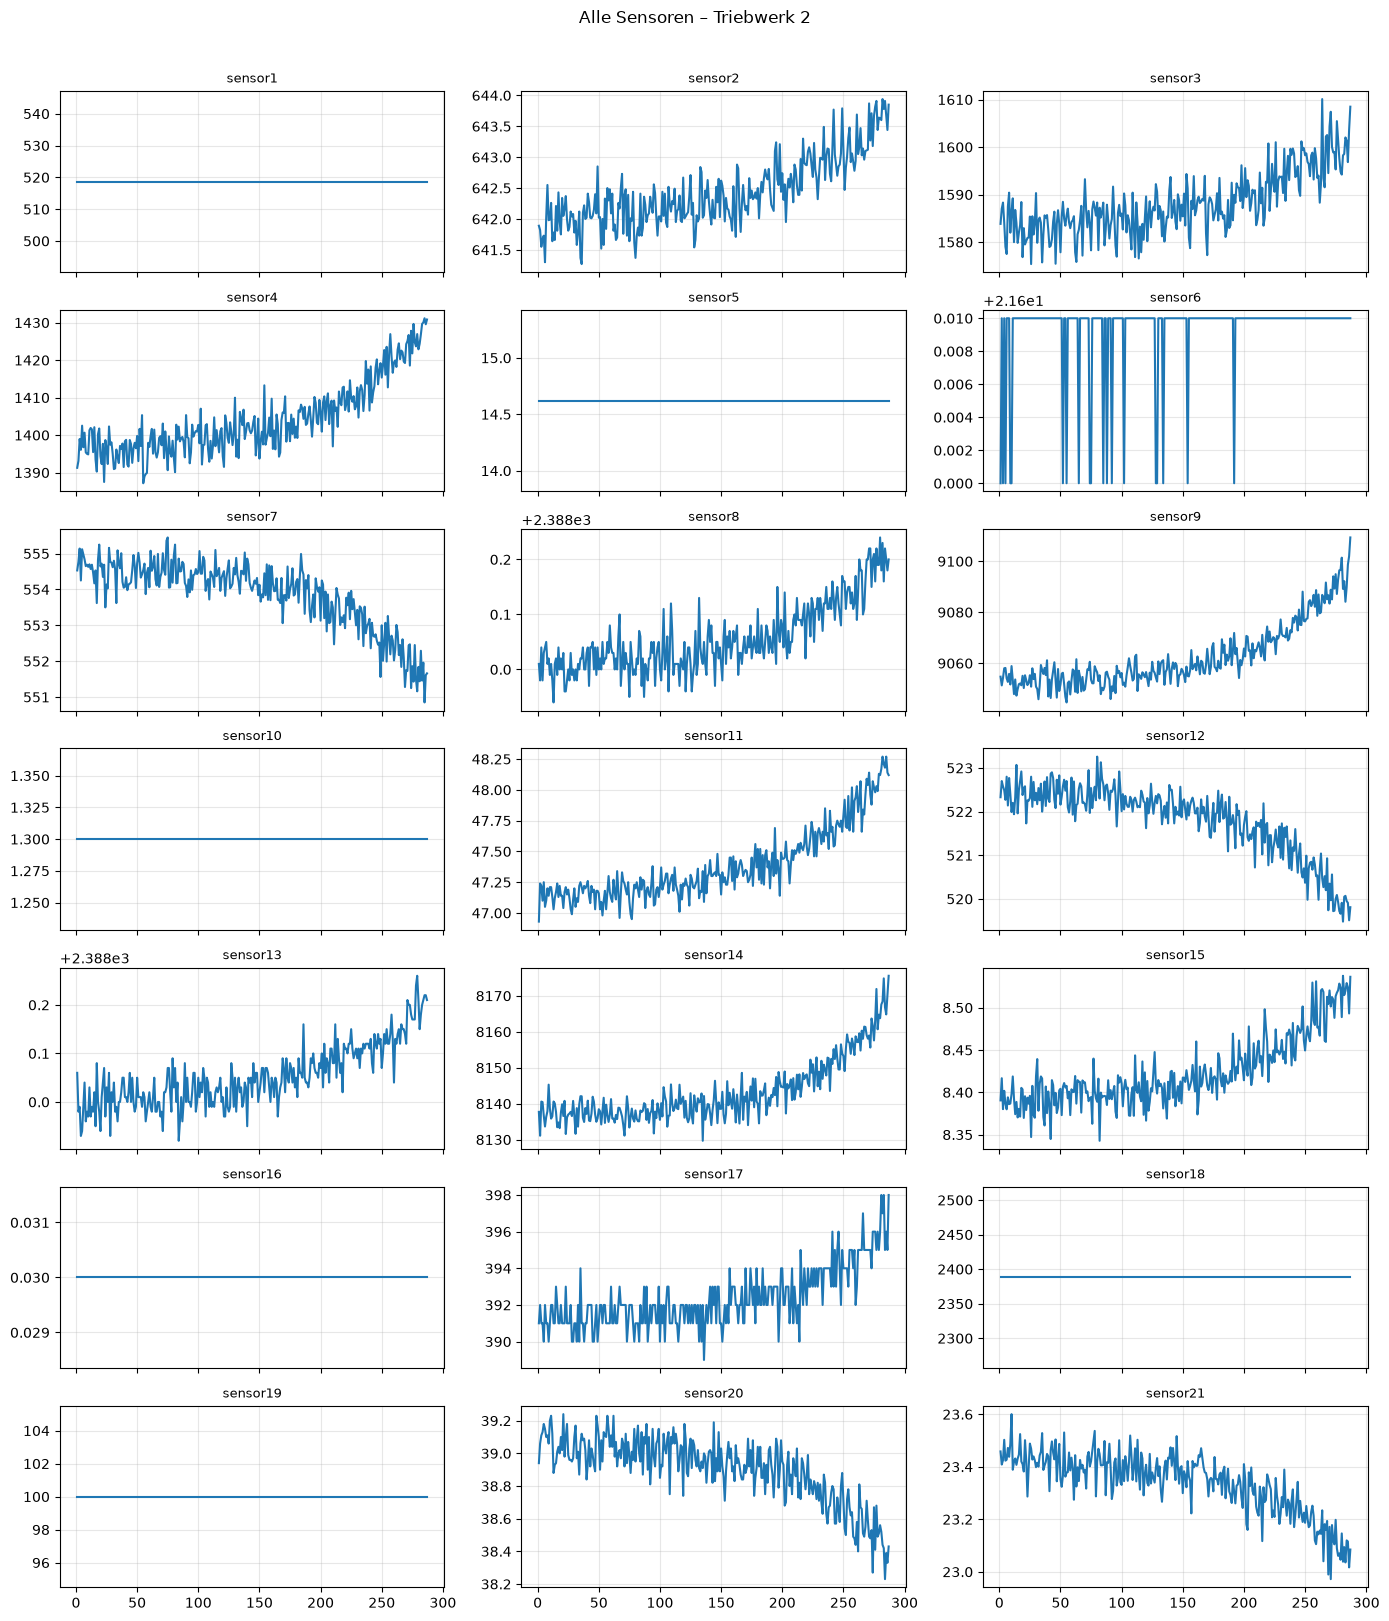

In [2]:
# ein Triebwerk, alle Sensoren

unit_id = 2
unit_df = machines[machines['unit'] == unit_id]

sensor_cols = [c for c in machines.columns if c.startswith('sensor')]

fig, axes = plt.subplots(7, 3, figsize=(14, 16), sharex=True)
for ax, col in zip(axes.flatten(), sensor_cols):
    ax.plot(unit_df['cycle'], unit_df[col])
    ax.set_title(col, fontsize=9)
fig.suptitle(f'Alle Sensoren – Triebwerk {unit_id}', y=1.01)
plt.tight_layout()
plt.show()

Sensoren, die dagegen direkt physikalische Zustände im Triebwerk messen (z.B. Temperaturen, Drücke,
Drehzahlen im Kern), zeigen einen klaren Trend über die Lebensdauer & sind für uns die relevanten Sensoren.

#### Preprocessing

Wir wählen beispielhaft einen Sensor aus, um die Preprocessing-Schritte konkret zu zeigen (`sensor11`). Für den späteren Vergleich zwischen allen Triebwerken wenden wir denselben Schritt auf jedes Triebwerk einzeln an.

In [3]:
print('Fehlende Werte gesamt:')
print(machines.isna().sum().sum())

# Prüfen, ob Zyklen pro Maschine lückenlos von 1 bis max durchnummeriert sind
def has_gaps(grp):
    expected = set(range(1, grp['cycle'].max() + 1))
    return expected - set(grp['cycle'])

gaps = machines.groupby('unit').apply(has_gaps)
n_with_gaps = (gaps.apply(len) > 0).sum()
print(f'Triebwerke mit Lücken im Zyklus-Raster: {n_with_gaps}')

Fehlende Werte gesamt:
0
Triebwerke mit Lücken im Zyklus-Raster: 0


In [4]:
print('Fehlende Werte gesamt:')
print(machines.isna().sum().sum())

# Prüfen, ob Zyklen pro Maschine lückenlos von 1 bis max durchnummeriert sind
def has_gaps(grp):
    expected = set(range(1, grp['cycle'].max() + 1))
    return expected - set(grp['cycle'])

gaps = machines.groupby('unit').apply(has_gaps)
n_with_gaps = (gaps.apply(len) > 0).sum()
print(f'Triebwerke mit Lücken im Zyklus-Raster: {n_with_gaps}')


step_to_step = unit_df['sensor11'].diff().abs().mean() # Näherungswert Rauschen
total_change = unit_df['sensor11'].max() - unit_df['sensor11'].min() # Näherungswert Trend

print(f'Mittlere Schwankung von Zyklus zu Zyklus: {step_to_step:.4f}')
print(f'Gesamtveränderung über die Lebensdauer: {total_change:.4f}')
print(f'Verhältnis (Rauschen / Trend): {step_to_step / total_change:.2%}')

Fehlende Werte gesamt:
0
Triebwerke mit Lücken im Zyklus-Raster: 0
Mittlere Schwankung von Zyklus zu Zyklus: 0.1083
Gesamtveränderung über die Lebensdauer: 1.3400
Verhältnis (Rauschen / Trend): 8.08%


Keine fehlenden Werte oder Lücken im Zyklus-Raster: Interpolation/Forward-Fill sind hier also
nicht nötig.

Wie stark schwankt `sensor11`?

- *Mittlere Schwankung von Zyklus zu Zyklus:* Durchschnitt der absoluten Differenzen zwischen aufeinanderfolgenden Messwerten (`|Wert[t] − Wert[t-1]|`). Wie stark springt der Sensor typischerweise von einem Zyklus zum nächsten, unabhängig
  vom langfristigen Verlauf?
- *Gesamtveränderung über die Lebensdauer:* Differenz zwischen Maximal- und Minimalwert über die gesamte Laufzeit des Triebwerks. Das entspricht dem eigentlichen Degradations-Trend, den wir erkennen wollen.
- *Verhältnis Rauschen/Trend:* setzt beide Werte ins Verhältnis. Hoher Wert: die Schwankung von Zyklus zu Zyklus ist im Vergleich zur Gesamtveränderung groß – der Trend ist schwer vom Rauschen zu unterscheiden. Niedriger Wert bedeutet: der Trend dominiert klar über
  das Rauschen.

Bei `sensor11` liegt dieses Verhältnis bei rund 8% , das Rauschen ist also spürbar, aber der Trend bleibt klar erkennbar. Für einen direkten Punkt-für-Punkt-Vergleich zwischen zwei Triebwerken (z. B. Euklidische Distanz) reicht aber schon dieses moderate Rauschen aus, um das Ergebnis zu verzerren – deshalb glätten wir `sensor11` im nächsten Schritt mit einem gleitenden Mittelwert.

In [5]:
ts = machines[machines['unit'] == 1].set_index('cycle')['sensor4']
ts.head()

cycle
1    1400.60
2    1403.14
3    1404.20
4    1401.87
5    1406.22
Name: sensor4, dtype: float64

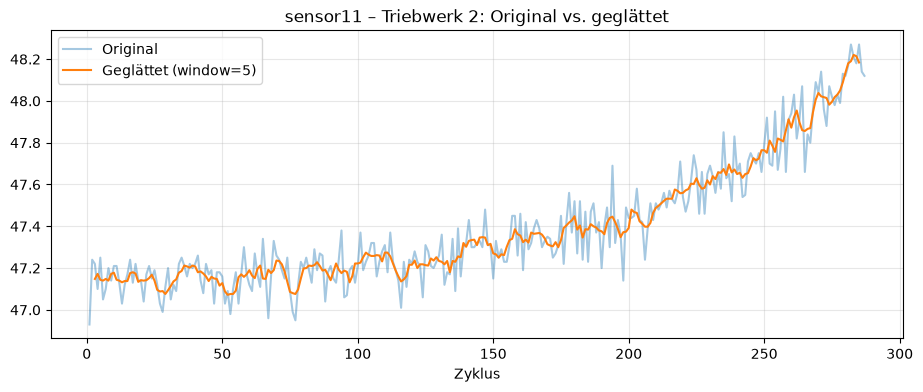

In [6]:
window = 5
unit_df = unit_df.copy()
unit_df['sensor11_smooth'] = unit_df['sensor11'].rolling(window, center=True).mean()

fig, ax = plt.subplots()
ax.plot(unit_df['cycle'], unit_df['sensor11'], alpha=0.4, label='Original')
ax.plot(unit_df['cycle'], unit_df['sensor11_smooth'], color='C1', label=f'Geglättet (window={window})')
ax.set_title(f'sensor11 – Triebwerk {unit_id}: Original vs. geglättet')
ax.set_xlabel('Zyklus')
ax.legend()
plt.show()

**Warum glätten wir vor einem Punkt-für-Punkt-Vergleich?**

Bei einem Vergleich wie der Euklidischen Distanz wird die Differenz an *jedem einzelnen Zyklus*
berechnet und aufsummiert. Rauschen ist dabei zufällig und bei zwei Triebwerken unabhängig
voneinander – selbst zwei Triebwerke mit identischem zugrundeliegendem Trend hätten durch das
Rauschen eine künstlich aufgeblähte Distanz. Das Ähnlichkeitsmaß könnte dann nicht mehr zuverlässig
zwischen "echtem Unterschied im Verhalten" und "zufälligem Messrauschen" unterscheiden.

Glättung reduziert diesen Zufallsanteil, sodass der Vergleich stärker den tatsächlichen Verlauf
(Trend/Form) widerspiegelt statt zufälliges Rauschen.

#### Dekomposition

Zur Vollständigkeit zeigen wir, wie eine klassische Dekomposition (Trend, Saisonalität, Rauschen) auf `sensor11` aussieht.

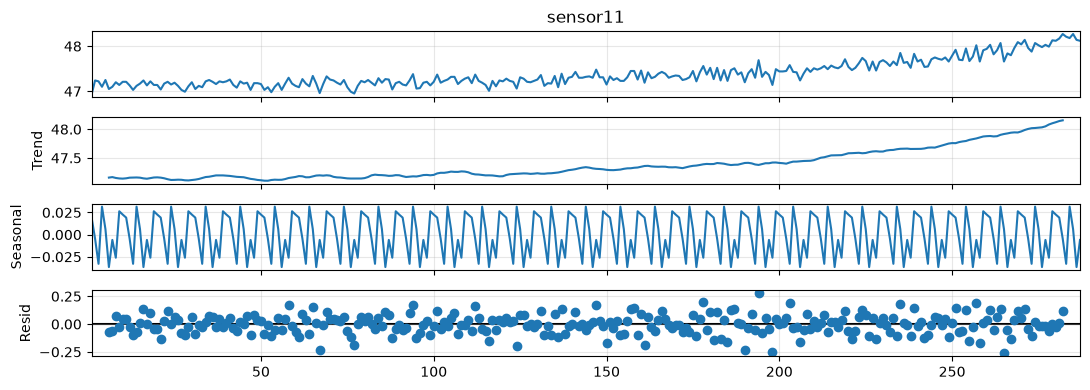

In [7]:
unit_df_indexed = unit_df.set_index('cycle')['sensor11']

result = seasonal_decompose(unit_df_indexed, model='additive', period=10)
result.plot()
plt.tight_layout()
plt.show()

**Hier aber sinnlos:** Degradationsdaten haben keine feste, wiederkehrende Periode – nur einen
einmaligen Alterungsverlauf. Die "Saisonal"-Komponente ist reines Artefakt des willkürlich
gewählten `period=10`, kein echtes Muster.

### Muster und Zusammenhänge zwischen Zeitreihen

#### Kurven vergleichbar machen

Um mehrere Triebwerke zu vergleichen, müssen wir zwei Probleme lösen:
- **Unterschiedliches Niveau/Skalierung** – wir normalisieren mit Z-Score
- **Unterschiedliche Länge** – jedes Triebwerk läuft unterschiedlich lange bis zum Ausfall

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


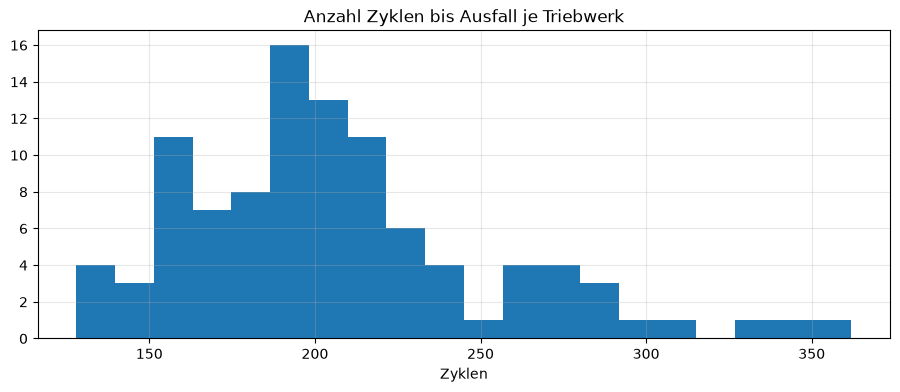

In [8]:
lengths = machines.groupby('unit')['cycle'].max()
print(lengths.describe())
lengths.hist(bins=20)
plt.title('Anzahl Zyklen bis Ausfall je Triebwerk')
plt.xlabel('Zyklen')
plt.show()

Für den Vergleich richten wir uns am **Ausfall** aus statt am Start: Zyklus 0 = Ausfall, negative Werte = Zyklen davor ("Remaining useful life"-Achse).  
So sind die Kurven am aussagekräftigsten Punkt (kurz vor Ausfall) ausgerichtet, auch wenn ihre Gesamtlänge unterschiedlich ist.

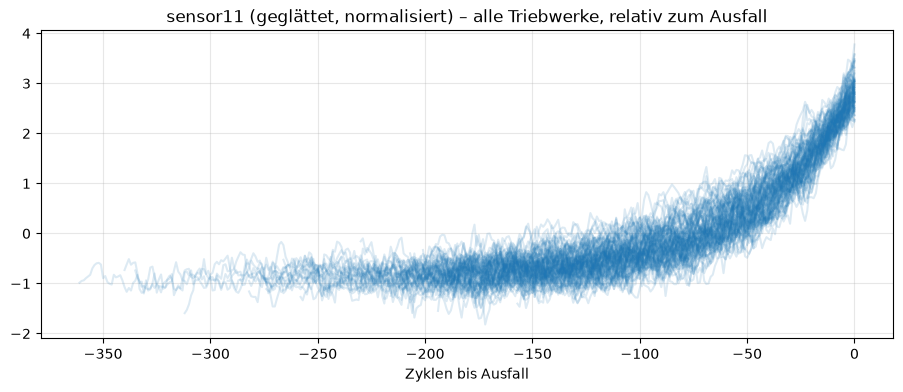

In [9]:
def prepare_series(grp, window=5):
    grp = grp.sort_values('cycle').copy()

    # Zeitachse relativ zum Ausfall ausrichten: 0 = letzter Zyklus, negativ = Zyklen davor
    grp['cycle_to_failure'] = grp['cycle'] - grp['cycle'].max()

    # Glättung pro Triebwerk einzeln (kein Verschmieren über Triebwerksgrenzen hinweg)
    grp['sensor11_smooth'] = grp['sensor11'].rolling(window, center=True, min_periods=1).mean()

    # Z-Score-Normalisierung: bringt jedes Triebwerk auf denselben Wertebereich,
    # damit die Form/der Verlauf vergleichbar wird statt das absolute Niveau
    grp['sensor11_norm'] = (
        (grp['sensor11_smooth'] - grp['sensor11_smooth'].mean())
        / grp['sensor11_smooth'].std()
    )
    return grp

# Auf jedes Triebwerk einzeln anwenden
prepared = pd.concat(
    [prepare_series(grp) for _, grp in machines.groupby('unit')],
    ignore_index=True
)

fig, ax = plt.subplots()
for uid, grp in prepared.groupby('unit'):
    # alpha niedrig, da 100 überlappende Kurven sonst unlesbar wären
    ax.plot(grp['cycle_to_failure'], grp['sensor11_norm'], alpha=0.15, color='C0')
ax.set_title('sensor11 (geglättet, normalisiert) – alle Triebwerke, relativ zum Ausfall')
ax.set_xlabel('Zyklen bis Ausfall')
plt.show()

Jetzt sind alle 100 Triebwerke direkt vergleichbar: gleiches Niveau (durch Z-Score) und am Ausfall
ausgerichtet statt am Start. Man sieht einen klaren gemeinsamen Trend – `sensor11` steigt bei den
meisten Triebwerken in den letzten Zyklen vor dem Ausfall deutlich an.

Gleichzeitig ist die Streuung um diesen Trend nicht bei allen Triebwerken gleich: manche Kurven
laufen eng am "Bündel" der anderen, andere weichen früher oder stärker ab. Genau diese
Abweichungen sind interessant – sie sind die Grundlage für den nächsten Schritt: Ähnlichkeit
zwischen Triebwerken messen und Gruppen (Cluster) mit ähnlichem Verhalten finden.

#### Ähnlichkeitsmaße

Wir vergleichen zwei Triebwerke mit formbasierten Methoden: Euklidische Distanz und DTW.

**Problem:** Euklidische Distanz braucht gleich lange Serien (Punkt-für-Punkt-Vergleich). Da jedes
Triebwerk unterschiedlich lange läuft, nutzen wir dafür nur ein gemeinsames Fenster – die letzten 30 Zyklen vor dem Ausfall, die bei **allen** Triebwerken vorhanden sind (das ist ohnehin der interessanteste Abschnitt, kurz vor dem Ausfall).

Länge Triebwerk 6: 30, Länge Triebwerk 8: 30


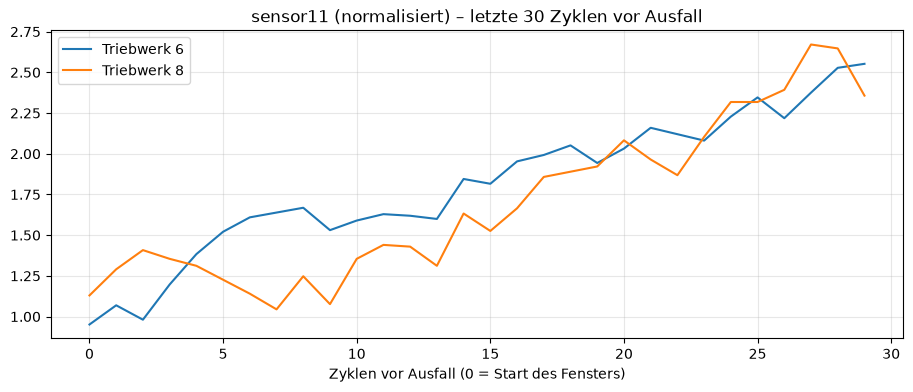

In [10]:
window_size = 30

def last_n_cycles(grp, n=window_size):
    return grp[grp['cycle_to_failure'] >= -n + 1].sort_values('cycle_to_failure')

unit_a, unit_b = 6, 8

series_a = last_n_cycles(prepared[prepared['unit'] == unit_a])['sensor11_norm'].values
series_b = last_n_cycles(prepared[prepared['unit'] == unit_b])['sensor11_norm'].values

print(f'Länge Triebwerk {unit_a}: {len(series_a)}, Länge Triebwerk {unit_b}: {len(series_b)}')

fig, ax = plt.subplots()
ax.plot(series_a, label=f'Triebwerk {unit_a}')
ax.plot(series_b, label=f'Triebwerk {unit_b}')
ax.set_title(f'sensor11 (normalisiert) – letzte {window_size} Zyklen vor Ausfall')
ax.set_xlabel('Zyklen vor Ausfall (0 = Start des Fensters)')
ax.legend()
plt.show()

##### Formbasierte Distanzmaße

Wir vergleichen Triebwerk 6 und 8 (letzte 30 Zyklen vor Ausfall) mit drei Maßen:
- **Euklidisch:** vergleicht Punkt für Punkt zur exakt gleichen Zeit – braucht zwingend gleich lange Serien
- **DTW:** erlaubt flexible Zuordnung der Zeitpunkte, toleriert also zeitliche Verschiebungen im Verlauf
- **Cross-Correlation:** verschiebt eine Kurve entlang der Zeitachse und sucht den Lag mit der größten Übereinstimmung

In [11]:
euclidean_dist = np.sqrt(np.sum((series_a - series_b) ** 2))
dtw_dist = dtw(series_a, series_b)

correlation = correlate(series_a, series_b, mode='full')
lags = np.arange(-len(series_b) + 1, len(series_a))
best_lag = lags[np.argmax(correlation)]

print(f'Euklidische Distanz: {euclidean_dist:.2f}')
print(f'DTW-Distanz: {dtw_dist:.2f}')
print(f'Bester Lag (Cross-Correlation): {best_lag} Zyklen')

Euklidische Distanz: 1.44
DTW-Distanz: 0.59
Bester Lag (Cross-Correlation): 0 Zyklen


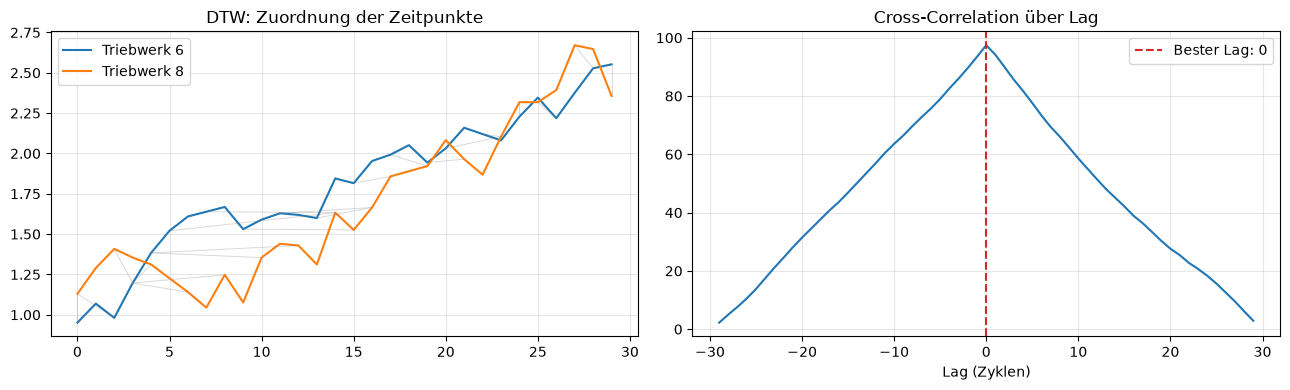

In [12]:
from tslearn.metrics import dtw_path

# DTW: zeigt, welche Punkte einander zugeordnet werden 
path, _ = dtw_path(series_a, series_b)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Links: DTW-Zuordnung
axes[0].plot(series_a, label=f'Triebwerk {unit_a}', color='C0')
axes[0].plot(series_b, label=f'Triebwerk {unit_b}', color='C1')
for i, j in path[::2]:  # nur jede 2. Verbindung zeigen, sonst zu unübersichtlich
    axes[0].plot([i, j], [series_a[i], series_b[j]], color='gray', alpha=0.3, linewidth=0.7)
axes[0].set_title('DTW: Zuordnung der Zeitpunkte')
axes[0].legend()

# Rechts: Cross-Correlation über alle Lags
axes[1].plot(lags, correlation)
axes[1].axvline(best_lag, color='C3', linestyle='--', label=f'Bester Lag: {best_lag}')
axes[1].set_title('Cross-Correlation über Lag')
axes[1].set_xlabel('Lag (Zyklen)')
axes[1].legend()

plt.tight_layout()
plt.show()

Visuell verlaufen beide Kurven eng beieinander – ähnliches Niveau, ähnliche Steigung, kein durchgehendes Auseinanderdriften.

- **Euklidisch = 1.44:** Strikter Punkt-für-Punkt-Vergleich. Je niedriger, desto ähnlicher (0 = identisch).
- **DTW = 0.59:** Niedriger als Euklidisch. Der Plot zeigt: zu Beginn (niedrige Zyklenzahl) sind die
Zuordnungslinien schräg. DTW ordnet Punkte dort zeitlich leicht versetzt zu, ein Zeichen für
kleine lokale Verzerrung. Später werden die Linien senkrecht – dort laufen beide Kurven zeitlich
synchron (Punkt i entspricht Punkt i).
- **Cross-Correlation, Lag = 0:** Kein zeitlicher Versatz zwischen den beiden Kurven.

**Fazit:** Triebwerk 6 und 8 altern über diese 30 Zyklen sichtbar ähnlich – ein gutes Beispiel dafür,
dass manche Triebwerke sich tatsächlich gleich verhalten. Genau diese Ähnlichkeiten systematisch zu erfassen, ist die Aufgabe des nächsten Schritts: Clustering über alle Triebwerke hinweg.

##### Merkmalsbasiert

Statt ganze Kurven zu vergleichen, extrahieren wir pro Triebwerk ein paar Kennzahlen (Lage,
Streuung, Trend) und vergleichen diese. Diese Methode schneller und robuster als Punkt-für-Punkt-Vergleiche,
büßt aber Information über die genaue Form ein.

Saisonale/spektrale Merkmale lassen wir hier weg – wie bei der Dekomposition gezeigt, gibt es hier
keine Periodizität, die sich sinnvoll erfassen ließe.

In [13]:
def get_window_series(unit_id, n=window_size):
    return last_n_cycles(prepared[prepared['unit'] == unit_id])['sensor11_norm'].values

def extract_features(unit_id):
    series = get_window_series(unit_id)
    return {
        'unit': unit_id,
        'mean': series.mean(),
        'std': series.std(),
        'slope': np.polyfit(np.arange(len(series)), series, 1)[0],  # lineare Steigung
    }

features_df = pd.DataFrame([extract_features(uid) for uid in machines['unit'].unique()])
features_df.head()

,unit,mean,std,slope
0,1,1.926522,0.476009,0.053299
1,2,2.238067,0.422284,0.045151
2,3,1.898551,0.712369,0.079598
3,4,1.898482,0.720653,0.079347
4,5,2.170549,0.476965,0.052128


Jede Zeile ist jetzt ein Triebwerk, beschrieben durch drei Kennzahlen statt 30
einzelnen Zeitpunkten:
- `mean`: durchschnittlicher Sensorwert in den letzten 30 Zyklen
- `std`: wie stark der Wert dabei schwankt (Streuung)
- `slope`: wie steil der Trend ansteigt (Steigung einer angepassten Geraden)

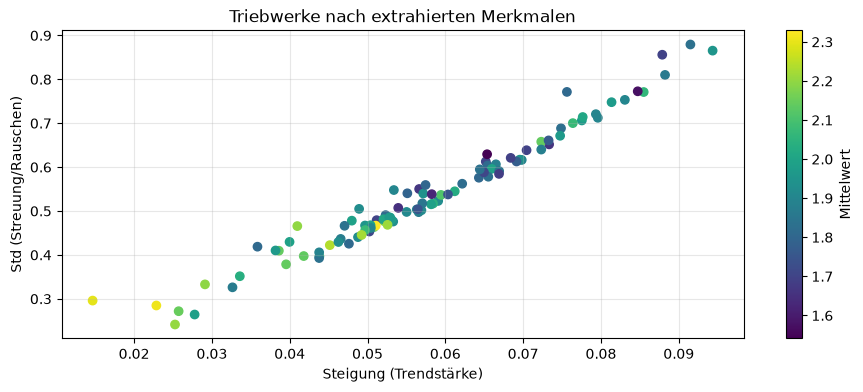

In [14]:
fig, ax = plt.subplots()
scatter = ax.scatter(features_df['slope'], features_df['std'], c=features_df['mean'], cmap='viridis')
ax.set_xlabel('Steigung (Trendstärke)')
ax.set_ylabel('Std (Streuung/Rauschen)')
plt.colorbar(scatter, label='Mittelwert')
ax.set_title('Triebwerke nach extrahierten Merkmalen')
plt.show()

Der Scatterplot zeigt alle 100 Triebwerke im Merkmalsraum (Steigung vs.
Streuung, Farbe = Mittelwert). Punkte nah beieinander = Triebwerke mit ähnlichem Trend/Streuung
in dieser Phase. Es zeigt sich ein klarer Zusammenhang: stärkerer Trend geht mit größerer Streuung
einher, plus zwei auffällige Ausreißer mit deutlich flacherem, ruhigerem Verlauf.

##### Modellbasiert

Bei diesem Ansatz passt man pro Triebwerk ein Zeitreihenmodell an (z. B. ARIMA, Exponential
Smoothing) und vergleicht die gelernten Modellparameter statt der Rohdaten.

**Für unseren Fall wenig geeignet:** ARIMA setzt stationäre Daten voraus – unsere Degradationskurven
sind aber bewusst nicht-stationär (der ganze Sinn ist ja der Trend zum Ausfall hin). Zusätzlich sind
unsere Fenster mit 30 Zyklen recht kurz für eine robuste Modellanpassung. Modellbasierte Verfahren
eignen sich besser für längere, stabilere Zeitreihen mit wiederkehrender Struktur (z. B. Energie-
oder Verbrauchsdaten mit Tages-/Wochenmustern) – daher verzichten wir hier auf eine Code-Demo.

##### Clustering

Bisher haben wir Ähnlichkeit nur zwischen **einzelnen Triebwerkspaaren** betrachtet. Jetzt nutzen
wir dieselben Prinzipien, um **alle 100 Triebwerke gleichzeitig** zu gruppieren – Triebwerke mit
ähnlichem Alterungsverlauf landen im selben Cluster.

Wir betrachten alle bereits erwähnten Verfahren kompakt nebeneinander: hierarchisches Clustering,
euklidisches k-Means, DTW-Clustering und k-Shape. So sehen wir direkt, wie stark die Wahl der
Distanzmethode das Ergebnis beeinflusst.

### Hierarchisches Clustering

Wir berechnen die DTW-Distanz zwischen allen Triebwerkspaaren und lassen daraus schrittweise ein
Dendrogramm aufbauen, ähnliche Triebwerke werden zuerst zusammengefasst.

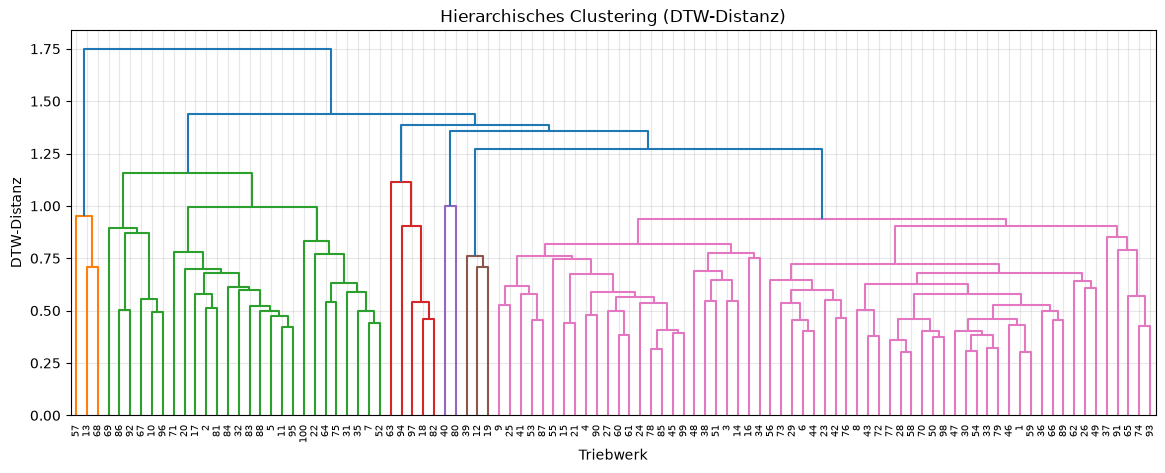

In [15]:
all_units = sorted(machines['unit'].unique())
all_series = np.array([get_window_series(uid) for uid in all_units])

dist_matrix = cdist_dtw(all_series)

Z = linkage(dist_matrix[np.triu_indices(len(dist_matrix), k=1)], method='average')

plt.figure(figsize=(14, 5))
dendrogram(Z, labels=all_units, leaf_rotation=90, leaf_font_size=7)
plt.title('Hierarchisches Clustering (DTW-Distanz)')
plt.xlabel('Triebwerk')
plt.ylabel('DTW-Distanz')
plt.show()

Je niedriger zwei Äste zusammenlaufen, desto ähnlicher die beiden Triebwerke (bzw. Cluster).   
Wir sehen eine klare Sturktur: eine große, dominante Gruppe (rechts, pink) mit den meisten Triebwerken, sowie mehrere kleinere, deutlicher abgegrenzte Gruppen. Besonders auffällig:
die Triebwerke in orange trennen sich am frühesten und deutlichsten vom Rest ab, dies sind mögliche Kandidaten für Ausreißer im Alterungsverhalten.

Um daraus konkrete Cluster zu bilden, müssen wir den Baum auf einer bestimmten Höhe "schneiden" –
wie viele Cluster dabei sinnvoll sind, klären wir später mit Silhouette Score und Elbow-Methode.

### k-Means (Euklidisch, DTW) & k-Shape

Drei Partitionierungs-Verfahren mit fester Cluster-Anzahl, die sich nur in der zugrundeliegenden
Distanz-/Ähnlichkeitsberechnung unterscheiden:
- **Euklidisches k-Means:** Cluster-Zentrum = Mittelwert, Distanz = Punkt-für-Punkt
- **DTW-Clustering:** wie k-Means, aber mit DTW-Distanz (toleriert Zeitversatz)
- **k-Shape:** nutzt eine normierte Cross-Correlation-basierte Distanz, fokussiert auf Kurvenform

In [16]:
n_clusters = 5  # wird später mit Silhouette/Elbow überprüft

# Euklidisches k-Means: Cluster-Zentrum = Mittelwert, Distanz = Punkt-für-Punkt
model_euclidean = TimeSeriesKMeans(n_clusters=n_clusters, metric='euclidean', random_state=42)
labels_euclidean = model_euclidean.fit_predict(all_series)

# DTW-Clustering: wie k-Means, aber mit DTW-Distanz (toleriert Zeitversatz)
model_dtw = TimeSeriesKMeans(n_clusters=n_clusters, metric='dtw', random_state=42)
labels_dtw = model_dtw.fit_predict(all_series)

# k-Shape braucht eine eigene, konsistente Normalisierung (nicht unsere manuelle Z-Normalisierung)
scaler = TimeSeriesScalerMeanVariance()
all_series_scaled = scaler.fit_transform(all_series)

# k-Shape: Cross-Correlation-basierte Distanz, fokussiert auf Kurvenform
model_kshape = KShape(n_clusters=n_clusters, random_state=42)
labels_kshape = model_kshape.fit_predict(all_series_scaled)

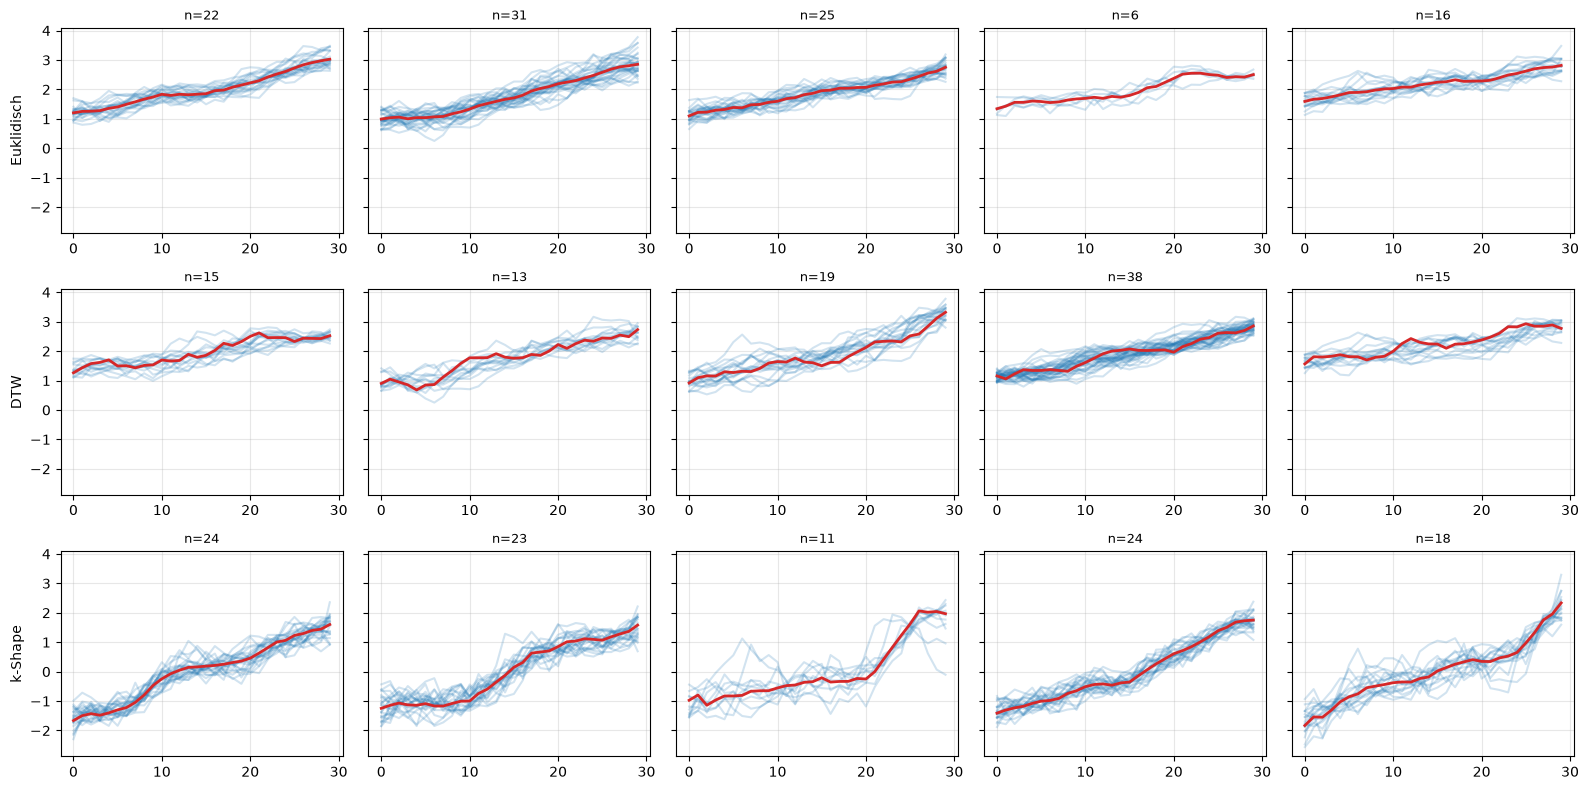

In [17]:
fig, axes = plt.subplots(3, n_clusters, figsize=(16, 8), sharey=True)

for row, (model, labels, name, data) in enumerate([
    (model_euclidean, labels_euclidean, 'Euklidisch', all_series),
    (model_dtw, labels_dtw, 'DTW', all_series),
    (model_kshape, labels_kshape, 'k-Shape', all_series_scaled),
]):
    for cluster_id in range(n_clusters):
        ax = axes[row, cluster_id]
        cluster_series = data[labels == cluster_id]
        for s in cluster_series:
            ax.plot(s, alpha=0.2, color='C0')
        ax.plot(model.cluster_centers_[cluster_id].ravel(), color='C3', linewidth=2)
        if cluster_id == 0:
            ax.set_ylabel(name)
        ax.set_title(f'n={len(cluster_series)}', fontsize=9)

plt.tight_layout()
plt.show()

**Wie liest man die Plots?** Jedes Panel ist ein Cluster: die blauen Linien sind die einzelnen
Triebwerke darin, die rote Linie ist das Cluster-Zentrum (der "typische" Verlauf). Die Zahl "n="
zeigt, wie viele Triebwerke im jeweiligen Cluster gelandet sind.

Ersichtliche Unterschiede zwischen den Methoden:
- **Euklidisch:** ausgeglichene Cluster-Größen (6-31), ein kleiner Cluster mit auffälligem Plateau
- **DTW:** ein großer Sammel-Cluster (n=38) für den "typischen" Verlauf, Rest trennt Ausreißer ab
- **k-Shape:** ähnlich ausgeglichene Größen wie Euklidisch, aber vielfältigere Kurvenformen
  (z. B. ein Cluster mit spätem, steilem Anstieg statt gleichmäßigem Verlauf)

Keine Methode liefert die "richtige" Aufteilung – jede gewichtet Ähnlichkeit anders.

#### Cluster-Bewertung

`n_clusters = 5` war bisher willkürlich gewählt. Wir prüfen jetzt systematisch mit Silhouette Score und Elbow-Methode, wie viele Cluster für unsere Daten sinnvoll sind – exemplarisch für DTW-Clustering, da es (wie oben gesehen) am klarsten zwischen "typischem Verlauf" und Ausreißern trennt.

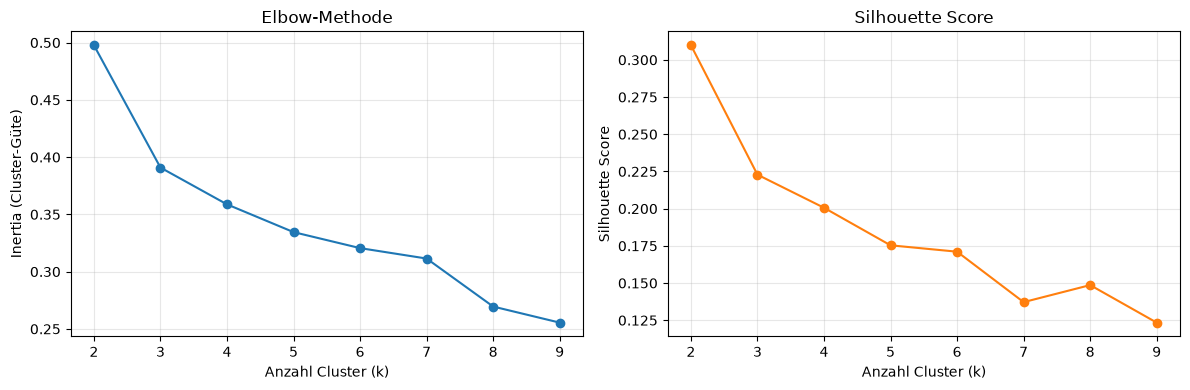

In [18]:
k_range = range(2, 10)
inertias = []
silhouette_scores = []

dist_matrix_full = cdist_dtw(all_series)  # einmal berechnen, für Silhouette wiederverwenden

for k in k_range:
    model = TimeSeriesKMeans(n_clusters=k, metric='dtw', random_state=42)
    labels_k = model.fit_predict(all_series)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(dist_matrix_full, labels_k, metric='precomputed'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow-Methode')
axes[0].set_xlabel('Anzahl Cluster (k)')
axes[0].set_ylabel('Inertia (Cluster-Güte)')

axes[1].plot(list(k_range), silhouette_scores, marker='o', color='C1')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Anzahl Cluster (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

- **Elbow-Methode:** die Inertia (Summe der Abstände innerhalb der Cluster) sinkt automatisch mit
steigendem k. Gesucht wird der Punkt, ab dem der Rückgang deutlich flacher wird (der "Ellbogen"), weil mehr Cluster ab dort kaum noch echten Zugewinn bringen.
- **Silhouette Score:** misst, wie gut jede Zeitreihe zu ihrem eigenen Cluster passt im Vergleich zu
anderen Clustern (1 = perfekt getrennt, 0 = Cluster überlappen, <0 = evtl. falsch zugeordnet).
Gesucht wird das k mit dem **höchsten** Wert.


Beide Kurven sagen hier dasselbe: **k=2** hat sowohl die höchste Inertia-Steigung (steilster Abfall
danach) als auch den mit Abstand höchsten Silhouette Score (~0.31). Ab k=3 flacht die Inertia deutlich
ab, und der Silhouette Score fällt spürbar. Beide Kennzahlen sprechen also für **k=2** als sinnvollste
Cluster-Anzahl.

Das ist inhaltlich eine überraschend grobe Aussage: mit dieser Methode/Fenster lassen sich die
Triebwerke am zuverlässigsten in nur **zwei** grobe Gruppen einteilen, nicht in viele feine
Untergruppen. Feinere Unterschiede (wie die 5 Cluster vorher) existieren zwar, sind aber statistisch
weniger klar voneinander abgegrenzt.

##### Finale Cluster-Aufteilung (k=2)

Basierend auf der Cluster-Bewertung verwenden wir jetzt **k=2** für alle vier Verfahren.

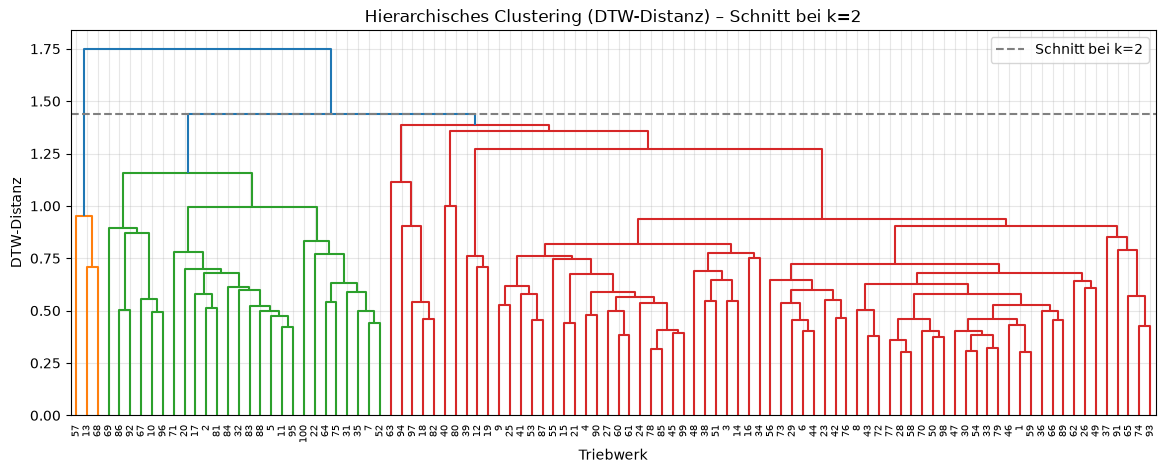

In [19]:
plt.figure(figsize=(14, 5))
dendrogram(Z, labels=all_units, leaf_rotation=90, leaf_font_size=7,
           color_threshold=Z[-2, 2])  # Höhe, bei der genau 2 Cluster entstehen
plt.axhline(Z[-2, 2], color='gray', linestyle='--', label='Schnitt bei k=2')
plt.title('Hierarchisches Clustering (DTW-Distanz) – Schnitt bei k=2')
plt.xlabel('Triebwerk')
plt.ylabel('DTW-Distanz')
plt.legend()
plt.show()

In [20]:
n_clusters = 2

model_euclidean = TimeSeriesKMeans(n_clusters=n_clusters, metric='euclidean', random_state=42)
labels_euclidean = model_euclidean.fit_predict(all_series)

model_dtw = TimeSeriesKMeans(n_clusters=n_clusters, metric='dtw', random_state=42)
labels_dtw = model_dtw.fit_predict(all_series)

model_kshape = KShape(n_clusters=n_clusters, random_state=42)
labels_kshape = model_kshape.fit_predict(all_series_scaled)

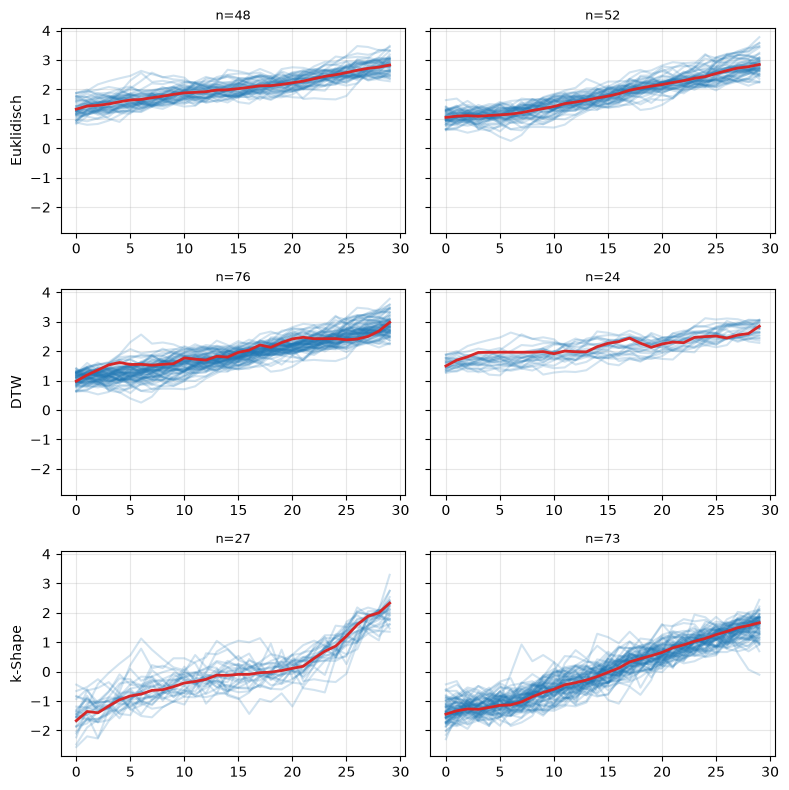

In [21]:
fig, axes = plt.subplots(3, n_clusters, figsize=(8, 8), sharey=True)

for row, (model, labels, name, data) in enumerate([
    (model_euclidean, labels_euclidean, 'Euklidisch', all_series),
    (model_dtw, labels_dtw, 'DTW', all_series),
    (model_kshape, labels_kshape, 'k-Shape', all_series_scaled),
]):
    for cluster_id in range(n_clusters):
        ax = axes[row, cluster_id]
        cluster_series = data[labels == cluster_id]
        for s in cluster_series:
            ax.plot(s, alpha=0.2, color='C0')
        ax.plot(model.cluster_centers_[cluster_id].ravel(), color='C3', linewidth=2)
        if cluster_id == 0:
            ax.set_ylabel(name)
        ax.set_title(f'n={len(cluster_series)}', fontsize=9)

plt.tight_layout()
plt.show()

Alle drei Verfahren finden bei k=2 eine ähnliche Grundidee: eine Gruppe mit **gleichmäßigerem, steilerem** Anstieg und eine Gruppe mit **flacherem Start**, die später aufholt oder plateauartig
verläuft. Die Gruppengrößen unterscheiden sich aber deutlich – Euklidisch teilt fast gleichmäßig
(48/52), DTW findet einen großen Hauptcluster mit kleinerer Abweichler-Gruppe (76/24, passend zum
Dendrogramm), k-Shape liegt dazwischen (27/73).

Damit haben wir eine grobe, aber konsistente Struktur: die meisten Triebwerke altern ähnlich, eine
kleinere Untergruppe weicht davon ab – wie stark diese Abweichung ist, hängt von der gewählten Methode ab.

#### Cluster-Interpretation

Der Algorithmus liefert nur Gruppen-Zuordnungen, aber keine Erklärung, warum diese Triebwerke
zusammengehören. Wir schauen uns das am Beispiel des k-Shape-Clusterings (k=2) genauer an, da es
zwei qualitativ unterschiedliche Muster zeigt: ein "spätes, abruptes" vs. ein "graduelles"
Alterungsverhalten.

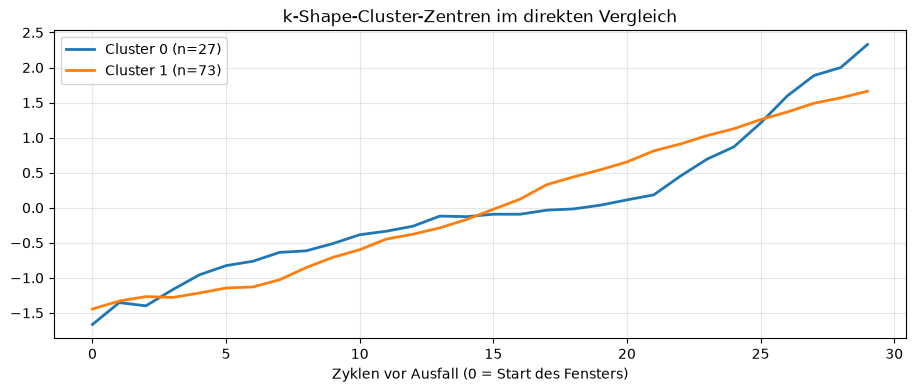

In [22]:
fig, ax = plt.subplots()
for cluster_id in range(2):
    center = model_kshape.cluster_centers_[cluster_id].ravel()
    ax.plot(center, label=f'Cluster {cluster_id} (n={np.sum(labels_kshape == cluster_id)})', linewidth=2)
ax.set_title('k-Shape-Cluster-Zentren im direkten Vergleich')
ax.set_xlabel('Zyklen vor Ausfall (0 = Start des Fensters)')
ax.legend()
plt.show()

- **Cluster 1 (orange, n=73):** steigt gleichmäßig und nahezu linear über die gesamte Fensterlänge.
- **Cluster 0 (blau, n=27):** verläuft in zwei Phasen – zunächst steiler Anstieg (Zyklus 0-5), dann
  ein Plateau mit kaum Veränderung (Zyklus 5-20), dann erneuter, steiler Anstieg zum Ende hin
  (Zyklus 20-29).

Ab dem Kreuzungspunkt (~Zyklus 14) liegt Cluster 0 durchgehend über Cluster 1, und der Abstand wird
zum Ende hin größer – Cluster 0 landet bei einem deutlich höheren Endniveau (~2.3 vs. ~1.65).


In [23]:
features_df['kshape_cluster'] = labels_kshape

features_df.groupby('kshape_cluster')[['mean', 'std', 'slope']].mean()

,mean,std,slope
kshape_cluster,,,
0,1.953531,0.519974,0.053233
1,1.912989,0.540890,0.058994


Hier zeigt sich kaum ein Unterschied zwischen den Clustern (Slope0.053 vs. 0.059, Std 0.52 vs. 0.54). Dies zeigt eine Grenze der merkmalsbasierten Betrachtung auf: eine lineare Steigung über die volle Fensterlänge mittelt den
Überkreuzungs-Effekt einfach heraus. Am Ende sind beide Cluster ähnlich weit gestiegen, nur der *Weg* dorthin unterscheidet sich. Genau solche zeitlichen Muster erkennt nur ein formbasierter Ansatz wie k-Shape, nicht die einfachen Kennzahlen.

**Fazit:** Die beiden Cluster unterscheiden sich nicht darin, *wie stark* sie altern, sondern *wann*
im beobachteten Fenster die stärkste Veränderung passiert – ein früher/schneller vs. später/dann
steiler Verlauf.

#### Wiederkehrende Muster

Methoden wie ACF, Matrix Profile undSTL suchen nach sich **wiederholenden** Abschnitten. Bei
Degradationsdaten ist das strukturell nicht gegeben – trotzdem zeigen wir kurz ACF, um zu sehen,
wie sich das Fehlen von Wiederholung dort äußert.

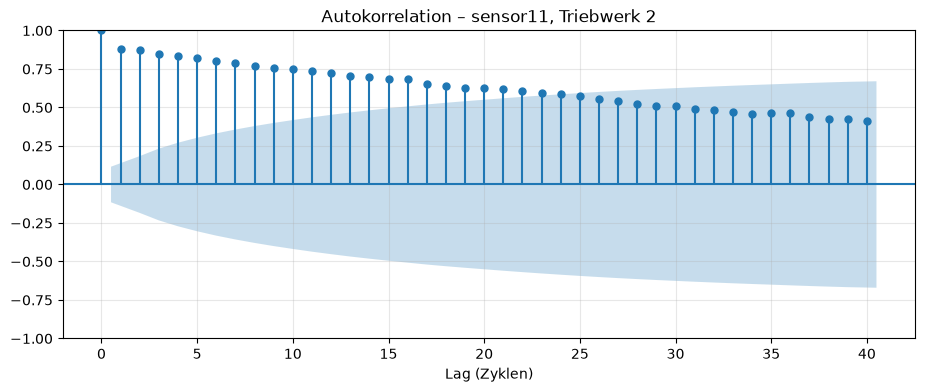

In [24]:
plot_acf(unit_df['sensor11'], lags=40)
plt.title('Autokorrelation – sensor11, Triebwerk 2')
plt.xlabel('Lag (Zyklen)')
plt.show()

Jeder Punkt zeigt, wie stark der Sensorwert mit sich selbst um "Lag" Zyklen versetzt korreliert. Bei periodischen Daten würde man wiederkehrende Spitzen bei festen
Lags sehen (z. B. alle 7 Lags bei wöchentlichen Mustern). Der blaue Bereich ist das
Konfidenzintervall – Werte darin gelten als statistisch nicht signifikant von 0 verschieden.

**Hier zu sehen:** Ein einziger, gleichmäßiger Abfall von 1.0 auf ~0.4 über 40 Zyklen, ohne erneute
Spitzen. Das bestätigt: kein periodisches Muster, nur ein Trend – benachbarte Zyklen ähneln sich
stark, die Ähnlichkeit nimmt mit wachsendem Abstand kontinuierlich ab. Für Degradationsdaten sind
ACF/Matrix Profile/STL damit keine zielführenden Werkzeuge.

#### Anomalien

Statt wiederkehrender Muster suchen wir hier nach Triebwerken, die vom typischen Verlauf abweichen,
gemessen als Distanz zum Cluster-Zentrum (k-Shape, k=2). Wir betrachten dabei **Cluster 1** (die größte, gleichmäßigste Gruppe, 73 Triebwerke) die einen
Referenzrahmen für "normales" Verhalten bietet.

In [25]:
def distance_to_center(series, cluster_id):
    center = model_kshape.cluster_centers_[cluster_id].ravel()
    return dtw_dist_fn(series, center)

features_df['dist_to_center'] = [
    distance_to_center(all_series_scaled[i], labels_kshape[i])
    for i in range(len(all_series_scaled))
]

cluster1_df = features_df[features_df['kshape_cluster'] == 1].copy()
cluster1_df.nlargest(5, 'dist_to_center')[['unit', 'dist_to_center']]

,unit,dist_to_center
68,69,3.504643
79,80,1.881680
74,75,1.831169
21,22,1.829264
63,64,1.817979


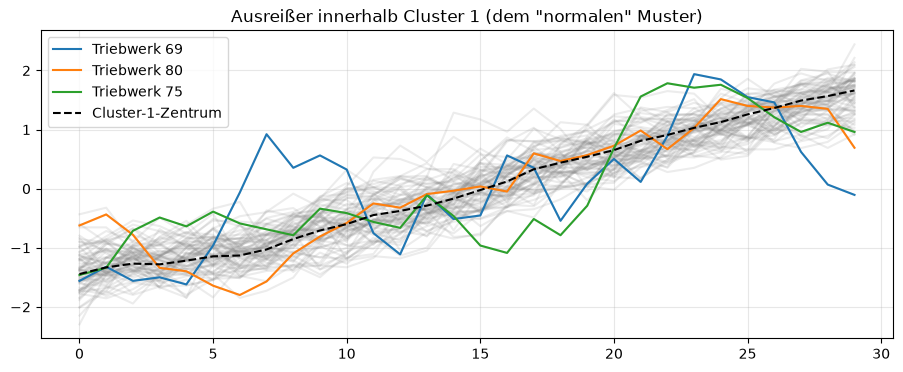

In [26]:
top_outliers = cluster1_df.nlargest(3, 'dist_to_center')['unit'].values

fig, ax = plt.subplots()
# alle "normalen" Cluster-1-Triebwerke im Hintergrund
for uid in cluster1_df['unit']:
    idx = list(all_units).index(uid)
    ax.plot(all_series_scaled[idx], color='gray', alpha=0.15)
# Ausreißer hervorgehoben
for uid in top_outliers:
    idx = list(all_units).index(uid)
    ax.plot(all_series_scaled[idx], label=f'Triebwerk {uid}')
ax.plot(model_kshape.cluster_centers_[1].ravel(), '--', color='black', label='Cluster-1-Zentrum')
ax.set_title('Ausreißer innerhalb Cluster 1 (dem "normalen" Muster)')
ax.legend()
plt.show()

**Was sehen wir?** Alle drei Ausreißer weichen nicht durchgehend ab, sondern zeigen jeweils eine
auffällige *Phase*:

- **Triebwerk 69:** stärkste Abweichung – ein früher, plötzlicher Ausschlag (Zyklus 7-9) und ein
  späteres Abdriften nach unten (ab Zyklus 25), während alle anderen weiter ansteigen.
- **Triebwerk 80:** startet ungewöhnlich hoch, gleicht sich aber ab Zyklus ~15 wieder an den Cluster-Verlauf an, fällt zum Schluss ab.
- **Triebwerk 75:** unruhiger, sprunghafter Verlauf in der ersten Hälfte, nähert sich danach ebenfalls wieder dem typischen Muster an.

**Einordnung:** Keiner der drei bricht komplett aus dem Cluster-Muster aus – sie zeigen eher
temporäre, lokale Abweichungen als einen grundsätzlich anderen Alterungsverlauf. Das unterscheidet
sie von den kompletten Cluster-0-Triebwerken, die durchgehend anders verlaufen (Plateau statt
gleichmäßigem Anstieg).

## Zusammenfassung

Anhand von CMAPSS FD001 sind wir den kompletten Workflow durchgegangen: von der Datenexploration über Preprocessing, Ähnlichkeitsmaße, Clustering bis zu Anomalien.

**Wichtigste Learnings:**

- **Preprocessing ist keine Formalität, sondern beeinflusst alles danach.** Rauschen in den Rohdaten
  hätte spätere Distanzmaße verzerrt.
- **Die Wahl der Distanzmethode verändert das Ergebnis spürbar.** Euklidisch, DTW und k-Shape lieferten
  unterschiedliche Cluster-Aufteilungen – "ähnlich" hängt davon ab, *wie* man Ähnlichkeit definiert (Punkt-für-Punkt, zeitversatz-tolerant, formfokussiert).
- **Statistische Kennzahlen können echte Unterschiede verschleiern.** Die k-Shape-Cluster zeigten
  deutlich unterschiedliche *Formen* (Plateau-dann-Absturz vs. gleichmäßiger Anstieg), aber fast
  identische Mittelwert/Std/Steigung – ein rein merkmalsbasierter Blick hätte diesen Unterschied
  übersehen.
- **Cluster-Bewertungskennzahlen (Silhouette, Elbow) sind ein Hinweis, keine Entscheidung.** Sie
  sprachen für k=2, aber erst der Blick auf die tatsächlichen Kurven zeigt, *was* dieser Unterschied
  inhaltlich bedeutet.
- **Anomalien sind oft nicht "komplett anders", sondern lokal/temporär abweichend.** Alle drei
  gefundenen Ausreißer in Cluster 1 wichen nur in einer bestimmten Phase vom typischen Verlauf ab,
  nicht durchgehend – Distanz-zum-Zentrum sagt nicht automatisch, *wann* oder *warum*.

**Wie könnte man diese Analyse erweitern?**

- **Andere Sensoren einbeziehen:** wir haben uns bewusst auf `sensor11` beschränkt – bei CMAPSS selbst ließe sich das multivariat erweitern (mehrere Sensoren
  gemeinsam clustern).
- **Fensterlänge variieren:** wir haben 30 Zyklen vor Ausfall gewählt – kürzere/längere Fenster oder
  der volle Verlauf statt nur das Ende könnten andere Cluster-Strukturen zeigen.
- **Cluster-Stabilität prüfen:** mehrfach mit unterschiedlichen `random_state`-Werten clustern und
  schauen, wie stabil die Zuordnungen sind (k-Means-Verfahren sind initialisierungsabhängig).
- **Zeitlichen Verlauf der Cluster-Zugehörigkeit anschauen:** gehört ein Triebwerk über die gesamte
  Lebensdauer konsistent zu "seinem" Cluster, oder wechselt es die Zugehörigkeit, je nachdem welches
  Zeitfenster man betrachtet?
- **Change Point Detection ergänzen**: statt nrur Distanz-zu-Zentrum,
gezielt den Zeitpunkt finden, ab dem sich ein Triebwerk von seinem bisherigen Verhalten entfernt.